# Tokenization & Preprocessing (Toy Study)

**Цель.** Показать, что выбор токенизации и предобработки влияет на:
- длину последовательности `n`,
- стоимость self-attention `O(n^2)`,
- распределение частот токенов.

Мы сравним:
1) word-level (split по словам)
2) char-level
3) toy-BPE (упрощённая частотная токенизация)

И отдельно посмотрим предобработку:
- stemming (toy)
- lemmatization (toy, словарик)

**Важно:** это учебный toy-эксперимент без внешних библиотек.

In [16]:
import re
import math
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## 1) Данные (маленький корпус)

Возьмём несколько строк (можно расширять). Важно, чтобы были повторяющиеся формы слов.

In [17]:
corpus = [
    "Transformers are transforming natural language processing.",
    "A transformer transforms sequences using self attention.",
    "Attention mechanisms attend to relevant tokens.",
    "Tokenization affects sequence length and attention cost.",
    "Models model modeling modeled: preprocessing can normalize forms.",
    "Running runs run: stemming and lemmatization reduce variants."
]

text = "\n".join(corpus)
print(text)

Transformers are transforming natural language processing.
A transformer transforms sequences using self attention.
Attention mechanisms attend to relevant tokens.
Tokenization affects sequence length and attention cost.
Models model modeling modeled: preprocessing can normalize forms.
Running runs run: stemming and lemmatization reduce variants.


## 2) Базовые токенизаторы

In [18]:
def tokenize_words(s: str):
    # слова/числа, нижний регистр
    return re.findall(r"[a-z0-9]+", s.lower())

def tokenize_chars(s: str):
    # только буквы/цифры/пробел -> уберём пробелы
    s = re.sub(r"[^a-z0-9]", "", s.lower())
    return list(s)

w_tokens = tokenize_words(text)
c_tokens = tokenize_chars(text)
print('word tokens:', len(w_tokens))
print('char tokens:', len(c_tokens))

word tokens: 42
char tokens: 299


## 3) Toy stemming и toy lemmatization

Без внешних библиотек сделаем:
- **stemming (toy)**: отрезаем типичные суффиксы
- **lemmatization (toy)**: небольшой словарик форм → лемма

Это не лингвистика уровня spaCy/NLTK, а демонстрация эффекта "нормализации".

In [19]:
def stem_toy(token: str):
    # очень грубо: частые суффиксы английского
    for suf in ["ing", "ed", "es", "s"]:
        if token.endswith(suf) and len(token) > len(suf) + 2:
            return token[:-len(suf)]
    return token

LEMMA = {
    "models": "model",
    "modeling": "model",
    "modeled": "model",
    "transforming": "transform",
    "transforms": "transform",
    "transformers": "transformer",
    "running": "run",
    "runs": "run",
}

def lemma_toy(token: str):
    return LEMMA.get(token, token)

w_stem = [stem_toy(t) for t in w_tokens]
w_lemma = [lemma_toy(t) for t in w_tokens]

print('unique words:', len(set(w_tokens)))
print('unique stem:', len(set(w_stem)))
print('unique lemma:', len(set(w_lemma)))

unique words: 39
unique stem: 33
unique lemma: 32


## 4) Стоимость self-attention как функция длины `n`

Память/время у vanilla self-attention растут как `n^2` (матрица внимания `n×n`).

Посмотрим, как разные токенизации меняют `n`, и сравним `n^2` (в относительных единицах).

word         n=  42   n^2=1764
word+stem    n=  42   n^2=1764
word+lemma   n=  42   n^2=1764
char         n= 299   n^2=89401


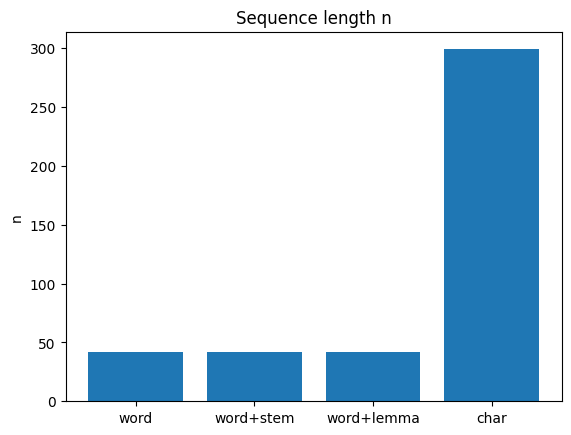

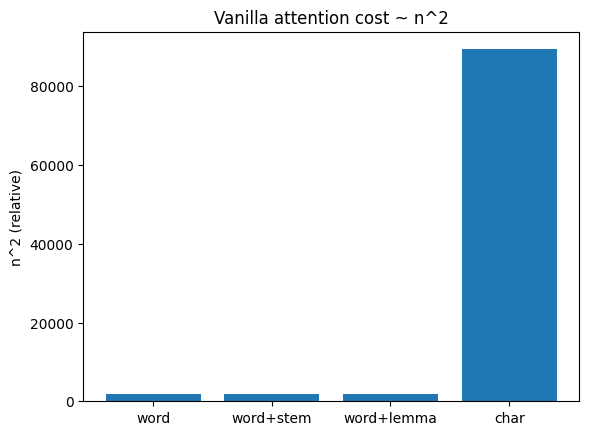

In [20]:
def attention_cost(n: int):
    # относительная стоимость vanilla self-attention ~ n^2
    return n * n


labels = ["word", "word+stem", "word+lemma", "char"]

n_word = len(w_tokens)
n_stem = len(w_stem)
n_lemma = len(w_lemma)
n_char = len(c_tokens)

ns = [n_word, n_stem, n_lemma, n_char]
costs = [attention_cost(n) for n in ns]

for lab, n, c in zip(labels, ns, costs):
    print(f"{lab:12s} n={n:4d}   n^2={c}")
    
# Графики
plt.figure()
plt.bar(labels, ns)
plt.title("Sequence length n")
plt.ylabel("n")
plt.show()

plt.figure()
plt.bar(labels, costs)
plt.title("Vanilla attention cost ~ n^2")
plt.ylabel("n^2 (relative)")
plt.show()


## 5) Частоты токенов: до/после нормализации

Сравним топ токенов и увидим, как stemming/lemmatization "склеивают" формы.

In [21]:
from collections import Counter

def topk(tokens, k=10):
    return Counter(tokens).most_common(k)

print('Top words:', topk(w_tokens))
print('Top stem :', topk(w_stem))
print('Top lemma:', topk(w_lemma))

Top words: [('attention', 3), ('and', 2), ('transformers', 1), ('are', 1), ('transforming', 1), ('natural', 1), ('language', 1), ('processing', 1), ('a', 1), ('transformer', 1)]
Top stem : [('model', 4), ('attention', 3), ('transformer', 2), ('transform', 2), ('and', 2), ('run', 2), ('are', 1), ('natural', 1), ('language', 1), ('process', 1)]
Top lemma: [('model', 4), ('attention', 3), ('run', 3), ('transformer', 2), ('transform', 2), ('and', 2), ('are', 1), ('natural', 1), ('language', 1), ('processing', 1)]


## 6) Toy-BPE (упрощённо)

Настоящий BPE сложнее, но идея такая: часто встречающиеся пары символов объединяются в один токен.

Сделаем игрушечный вариант:
- стартуем с char tokens внутри каждого слова
- несколько шагов объединяем самую частую пару
- измеряем итоговую длину последовательности

**Цель:** увидеть, что subword токенизация — компромисс между word и char.

toy-BPE length: 183 (start char-level: 341)


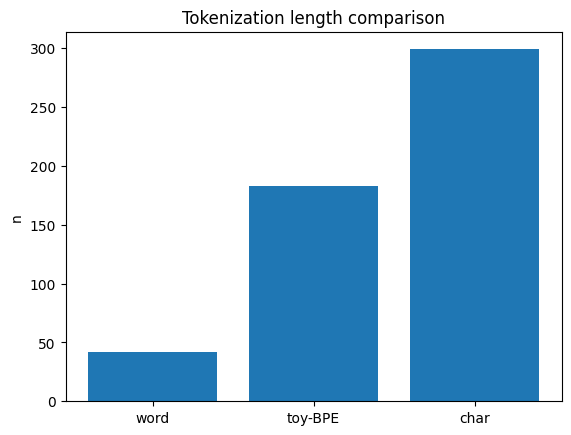

In [22]:
from collections import Counter

def word_to_chars(word: str):
    # символы + маркер конца слова
    return list(word) + ["_"]


def get_pair_counts(seqs):
    cnt = Counter()
    for s in seqs:
        for i in range(len(s) - 1):
            cnt[(s[i], s[i + 1])] += 1
    return cnt


def merge_pair(seqs, pair):
    a, b = pair
    merged = a + b
    new_seqs = []

    for s in seqs:
        out = []
        i = 0
        while i < len(s):
            if i < len(s) - 1 and s[i] == a and s[i + 1] == b:
                out.append(merged)
                i += 2
            else:
                out.append(s[i])
                i += 1
        new_seqs.append(out)

    return new_seqs


# стартуем с char-level
words = tokenize_words(text)
seqs = [word_to_chars(w) for w in words]


def flatten(seqs):
    out = []
    for s in seqs:
        out.extend(s)
    return out


n0 = len(flatten(seqs))
steps = 30

for _ in range(steps):
    pair_counts = get_pair_counts(seqs)
    if not pair_counts:
        break

    best_pair, best_cnt = pair_counts.most_common(1)[0]
    if best_cnt < 2:
        break

    seqs = merge_pair(seqs, best_pair)

nbpe = len(flatten(seqs))

print(f"toy-BPE length: {nbpe} (start char-level: {n0})")

plt.figure()
plt.bar(["word", "toy-BPE", "char"], [n_word, nbpe, n_char])
plt.title("Tokenization length comparison")
plt.ylabel("n")
plt.show()


## 7) Вывод

- Tokenization напрямую влияет на длину `n` → стоимость внимания `n^2`.
- Char-level даёт огромный `n`, word-level — минимальный `n`, subword (toy-BPE) — компромисс.
- Stemming/lemmatization уменьшают число уникальных форм и меняют частоты токенов.

Это важная инженерная часть NLP: до выбора модели часто решает токенизация.